# **Quantified Self : An Excursion in Goal Setting**
## Introduction

On January first, 2026, I set myself 11 goals for the year. These goals ranged across all facets of my life, with 6 of them being long term goals that I would revisit at year's end, while the other 5 would be tracked daily. Some goals are dedicated to physical health, challenging myself to run more often and do pushups before bed, while others are dedicated to learning, such as reading more books and learning a new language. Still others are meant to push me out of my comfort zone, with goals of landing a summer job and asking out a girl I liked. More on that later. 

Following April's recent conclusion, we are officially a fourth of the way through the year. In this project, we will be conducting Exploratory Data Analysis on the 5 daily goals I set for myself to determine if I am still holding myself accountable to them. For each goal, I will give it a letter grade based on how well I stuck to it. Later on, we will apply classification machine learning algorithms to determine how my performance looks on a daily basis.

The primary stakeholder is myself, as I stand to gain the most from this process, but secondary stakeholders include my parents who will recieve this presentation at the end of this year, as well as classmates who can hopefully glean insight from my experience with long-term and short-term goalsetting.

Without further ado, let's get into the dataset. Data was recorded by hand nightly in the spreadsheet below:

<img src='spreadsheet_snapshot.png' alt='SpreadsheetView'> 

The data was then loaded into a csv file of form:

<img src='habits_csv_snapshot.png' width = 600 height = 300>

For further analysis, I downloaded my instagram usage data from the last year to monitor that goal. I was interested in finding out how much time I spent on Instagram from before I deleted it versus after. Although Instagram doesn't show you a comprehensive hours spent on the app, I chose to use the amount of posts that I liked as a good indicator of how much time I was spending. Just in the last year, I had liked over 4,000 posts, and Instagram has the data for all of them.

So, my 'Liked Posts' JSON data was added and eventually merged with my original dataset.

### Attributes

The data has the following attributes:
- Date (Index)
- Instagram Banished (Int):  1 = No Instagram or social media usage that day, 0 = Any Instagram or social media usage that day
- Miles Ran (Float): Distance in miles ran that day
- Pushups (Int): Pushups completed that day
- Duolingo (Int): 1 = Completed daily Duolingo lesson, 0 = Did not complete daily Duolingo lesson
- Floss (Int): 1 = Flossed teeth that day, 0 = Did not floss teeth that day
- Liked Posts (Int): How many instagram posts I liked that day
- Day of the week

Data is recorded manually every night before I go to bed. Data ranged from January First to April 22nd for 112 instances of data. 

## Data Cleaning

Let's load our data from our csv files and perform any data cleaning we need to do:

In [1]:
import pandas as pd
import utilities as utilities

habits_df = pd.read_csv('habits.csv')
insta_df = utilities.clean_and_load_insta()

### Habits Cleaning

The habits dataframe posed only one main problem: Days where I did not run or do pushups were stored as NaN values, which is not ideal for data analysis. So, a simple fix was to fill those rows with zeroes using;
```python
.fillna(0)
```
for our 'Miles Ran' and 'Pushups' columns. The function below also sets 'Date' to be the index for the data. 

In [2]:
clean_habits_df = utilities.clean_habits(habits_df)

### Instagram Cleaning

The instagram dataframe did not require much data cleaning either, although it was important to ensure that the dates were being loaded the same way. Data from the liked_posts json file was being stored as a timestamp, so using the following loop we:
- Extract the timestamp data from the json file
- Convert the timestamp to a m/d/y format
- Append it to a dict of each day and the amount of liked posts per day
```python
for item in range(len(json_obj)):
        timestamp = json_obj[item]['timestamp']
        day_name = datetime.fromtimestamp(timestamp).strftime('%m/%d/%y')
        daily_groups.setdefault(day_name, []).append(timestamp)

counts_dict = {day: len(items) for day, items in daily_groups.items()}
```

This resulting dictionary is then turned into a dataframe object.

Next, we will need to merge our habits dataframe with the instagram dataframe. Both dataframes have the attribute 'Date', so we are able to perform an outer join on that attribute, being careful to make sure the dates are being stored the same way. We will also fill any NaN values in the liked posts column with zeroes.

In [3]:
clean_habits_df.index = pd.to_datetime(clean_habits_df.index).strftime('%m/%d/%y')
merged_df = pd.merge(clean_habits_df,insta_df,left_index=True,right_on='Date',how='outer')
merged_df['Date']= pd.to_datetime(merged_df['Date'])
merged_df.set_index('Date',inplace=True)
merged_df['Liked Posts'] = merged_df['Liked Posts'].fillna(0)
merged_df.to_csv('final_df.csv')

/var/folders/1r/bf66r9w17t14kkdq6dsyvlnr0000gn/T/ipykernel_25052/835811750.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_habits_df.index = pd.to_datetime(clean_habits_df.index).strftime('%m/%d/%y')
/var/folders/1r/bf66r9w17t14kkdq6dsyvlnr0000gn/T/ipykernel_25052/835811750.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['Date']= pd.to_datetime(merged_df['Date'])


Now we have our final dataframe!

### Challenges
The main challenge faced with loading, cleaning, and merging the Dataframes was making sure the 'Date' attributes were handled correctly. I was stuck on figuring out how to merge the tables for a long time, until I realized that one table was storing dates as a Datetime object, while the other was storing them as strings. Once that issue was resolved, merging the tables was complete.

## Data Analysis

One of the main things I am curious about is what our data looks like on each day of the week. So, let's group by day and see what patterns emerge:

In [4]:
grouped_by_dotw = clean_habits_df.groupby('Day of the Week')

weekend_df = pd.concat([grouped_by_dotw.get_group('Friday'),grouped_by_dotw.get_group('Saturday')])
weekday_df = pd.concat([grouped_by_dotw.get_group('Monday'),grouped_by_dotw.get_group('Tuesday'),grouped_by_dotw.get_group('Wednesday'),grouped_by_dotw.get_group('Thursday'),grouped_by_dotw.get_group('Friday')])

print(grouped_by_dotw.sum('Flossed'))

                 Instagram Banished  Miles Ran  Pushups  Duolingo  Flossed
Day of the Week                                                           
Friday                           11      35.03    144.0        15       10
Monday                           13      14.68    250.0        14        9
Saturday                         11     118.06     70.0        12        6
Sunday                            8      18.22    241.0        16       11
Thursday                         14      59.99    291.0        15       10
Tuesday                          12      58.99    330.0        15       13
Wednesday                        15      86.05    285.0        16       11


In [5]:
print(grouped_by_dotw.max('Flossed'))

                 Instagram Banished  Miles Ran  Pushups  Duolingo  Flossed
Day of the Week                                                           
Friday                            1      15.00     39.0         1        1
Monday                            1       7.16     80.0         1        1
Saturday                          1      19.00     35.0         1        1
Sunday                            1      14.75     36.0         1        1
Thursday                          1       8.00     41.0         1        1
Tuesday                           1       8.18     80.0         1        1
Wednesday                         1       8.40     80.0         1        1


Here are the main patterns I am curious about:
- How my instagram usage changed over time
- How my pushups goal performed over time
- Whether or not I floss more on weekends
- To what extent I stick to some goals more than others

### Instagram

For this analysis, data was grouped weekly to observe total liked posts.

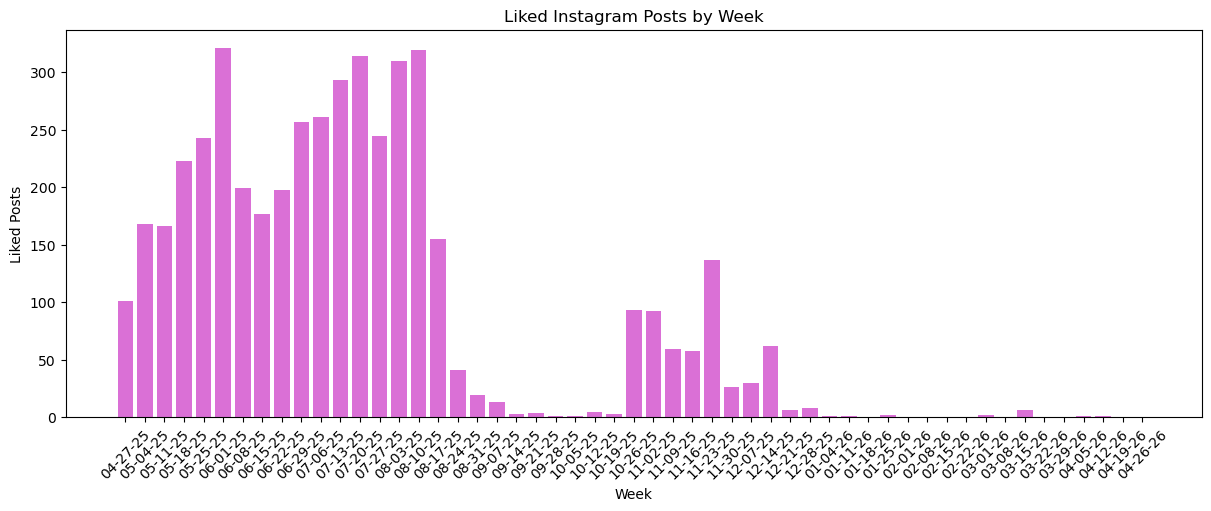

In [6]:
utilities.make_insta_graph(merged_df)

From the graph, you can certainly tell when I had more time to kill during the summer months, as well as towards the end of first semester when classes were a little easier. Once Janury first hit, we see the likes drop off completely, which is a good indicator that I have been sticking well to my goal.

### Flossing

One experiment I was curious about was whether or not I flossed more on weekends versus weekdays. From personal experience, it feels like I always get caught up in the hubbub on weekends and forget to floss, but let's see if this is actually the case or not.

We will be conducting a two-tailed difference of two proportions test. Since this wasn't a test we covered in class, the formula is included below. 

$\begin{equation} \frac{\hat{p}_{1}-\hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})(\frac{1}{n_{1}}+\frac{1}{n_{2}})}}              \end{equation}$
Where:
-  $\hat{p}_1$ is the proportion of weekdays that I flossed
- $\hat{p}_2$ is the proportion of weekends that I flossed.
- $\hat{p}$ is the pooled proportion of both groups combined.

Using our 5 Step Hypothesis Testing Process:
1. Declare Null and Alternative Hypothesis:
- $H_{0}: \hat{p}_1 = \hat{p}_2$
- $H_{A}: \hat{p}_1 \neq \hat{p}_2$
2. Declare Level of Significance:
- We will use a .10 level of significance.
3. Compute Test Statistic:
- We will compute this below:

In [7]:
from statsmodels.stats.proportion import proportions_ztest

weekday, weekend = utilities.flossing_hyp_test(merged_df)

Test Statistic: -1.597
PValue: 0.110


3. (cont.)
- So, our test statistic is -1.597
4. (and 5); Formulate Decision Rule and Draw Conclusions
- Combining our steps 4 and 5, since our pvalue of .11 was greater than our declared significance level of .10, we do not have significant evidence to reject our null hypothesis that $\hat{p}_1 =\hat{p}_2$. Although there is reasonable evidence to suggest I do not floss as much on weekends, it is not enough to be statistically significant. 

The following program creates a pie chart to represent the weekday and weekend flossing proportions.

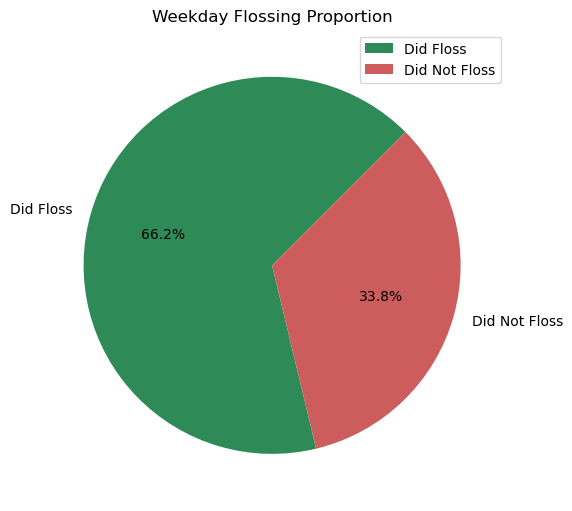

In [11]:
utilities.pie_flossing(weekday,'Weekday')

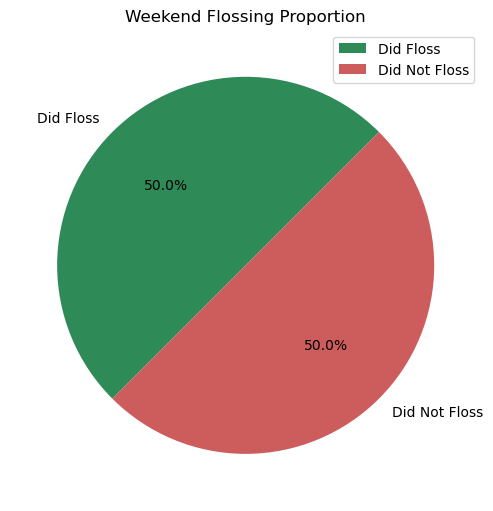

In [10]:
utilities.pie_flossing(weekend,'Weekend')

#### Takeaway:
Although the difference wasn't enough to be statistically significant, I can still definitely be better about flossing on weekends.

### Pushups

As the weeks went on, my New Year's motivation started to wane. Let's look at how the goal of doing pushups performed over the 4 months:

In [9]:
# utilities.pushups_display(clean_habits_df)
print(dir(utilities))


['ConfusionMatrixDisplay', 'DecisionTreeClassifier', 'KNeighborsClassifier', 'MinMaxScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accuracy_score', 'clean_activities', 'clean_and_load_insta', 'clean_habits', 'compute_proportions', 'conf_int', 'confusion_matrix', 'datetime', 'flossing_hyp_test', 'json', 'main', 'make_insta_graph', 'np', 'pd', 'pie_flossing', 'plt', 'proportions_ztest', 'pushups_display', 'pushups_f_test', 'stats', 'timezone', 'train_test_split']


## Machine Learning

We are curious about the question of whether or not we can predict what day of the week it is based on my habits. I predict the model will be able to do this with some degree of accuracy since my running schedule is pretty consistent. However, predicting a day of the week is difficult, since there is essentially a 1/7 shot. So, any accuracy higher than $1/7 = .1428$% is pretty good. 

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

utilities.decision_tree(merged_df)